In [5]:
%pip install -q pandas numpy matplotlib seaborn scipy openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# 1. Import libraries and load the dataset
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Prefer a file uploaded in Colab; otherwise look for a CSV/Excel file in the working directory.
file_name = None

try:
    from google.colab import files
    print("Please upload a CSV or Excel file when prompted.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No file was uploaded.")
    file_name = next(iter(uploaded))
except ImportError:
    local_candidates = sorted(glob.glob("*.csv") + glob.glob("*.xlsx") + glob.glob("*.xls"))
    if not local_candidates:
        raise FileNotFoundError(
            "No CSV/Excel file found in the current working directory. "
            "Place the dataset in this folder or upload it in Colab and rerun this cell."
        )
    file_name = local_candidates[0]
    print(f"Using local file: {file_name}")

if file_name.lower().endswith(".csv"):
    df = pd.read_csv(file_name)
elif file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)
else:
    raise ValueError(f"Unsupported file type: {file_name}")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head())


Using local file: retail_sales_transactions_24_months.csv
Dataset shape: (6000, 12)

Columns:
['transaction_id', 'date', 'store_id', 'product_category', 'sku', 'units_sold', 'revenue', 'discount_pct', 'customer_id', 'customer_segment', 'region', 'channel']


,transaction_id,date,store_id,product_category,sku,units_sold,revenue,discount_pct,customer_id,customer_segment,region,channel
0,TXN-000657,2024-01-01,SOUTH-02,Home & Kitchen,HOME-2004,1,16.06,19.65,CUST-00300,New,South,In-store
1,TXN-000885,2024-01-01,CENTRAL-02,Apparel,APP-3002,4,158.77,0.74,CUST-00806,New,Central,In-store
2,TXN-001407,2024-01-01,WEST-03,Apparel,APP-3002,2,79.54,0.55,CUST-01041,New,West,In-store
3,TXN-003507,2024-01-01,CENTRAL-03,Electronics,ELEC-1002,1,89.24,0.29,CUST-01401,New,Central,Online
4,TXN-004157,2024-01-01,SOUTH-02,Beauty,BEAU-4003,3,83.83,20.16,CUST-00150,New,South,In-store


In [7]:
# 2. Prepare data types and validate required fields
# Accept common column-name variations and normalize them to the expected names.
normalized = {c.lower(): c for c in df.columns}
name_map = {}
for target, aliases in {
    "date": ["date", "order_date", "transaction_date", "purchase_date"],
    "product_category": ["product_category", "category", "product_type"],
    "revenue": ["revenue", "total_amount", "total_sales", "sales_amount", "sales", "amount"],
    "discount_pct": ["discount_pct", "discount_rate", "discount"],
    "channel": ["channel", "sales_channel", "platform"],
    "transaction_id": ["transaction_id", "order_id", "invoice_id", "invoice_no", "txn_id"],
}.items():
    for alias in aliases:
        if alias.lower() in normalized:
            name_map[target] = normalized[alias.lower()]
            break

missing_columns = [col for col in ["date", "product_category", "revenue", "discount_pct", "channel", "transaction_id"] if col not in name_map]
if missing_columns:
    raise ValueError(
        "Required columns missing after matching common aliases. "
        f"Missing: {missing_columns}. Available columns: {list(df.columns)}"
    )

for target, source in name_map.items():
    if target != source:
        df = df.rename(columns={source: target})

required_columns = ["date", "product_category", "revenue", "discount_pct", "channel", "transaction_id"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' was not found in the data after normalization.")

# Standardize dtypes
for col in ["date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
for col in ["revenue", "discount_pct"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values in required columns:")
display(df[required_columns].isna().sum().to_frame("missing_count"))

# Exclude rows missing essential analysis fields; preserve original df for audit.
analysis_df = df.dropna(subset=required_columns).copy()
print("Rows retained for analysis:", len(analysis_df))
print("Date range:", analysis_df["date"].min().date(), "to", analysis_df["date"].max().date())


Missing values in required columns:


,missing_count
date,0
product_category,0
revenue,0
discount_pct,0
channel,0
transaction_id,0


Rows retained for analysis: 6000
Date range: 2024-01-01 to 2025-12-31


,month,revenue,mom_change_pct
0,2024-01-01 00:00:00,"52,555.84",+nan%
1,2024-02-01 00:00:00,"44,465.80",-15.39%
2,2024-03-01 00:00:00,"57,583.04",+29.50%
3,2024-04-01 00:00:00,"64,012.00",+11.16%
4,2024-05-01 00:00:00,"48,966.72",-23.50%
5,2024-06-01 00:00:00,"56,383.96",+15.15%
6,2024-07-01 00:00:00,"62,585.46",+11.00%
7,2024-08-01 00:00:00,"69,533.75",+11.10%
8,2024-09-01 00:00:00,"63,545.02",-8.61%
9,2024-10-01 00:00:00,"77,232.63",+21.54%


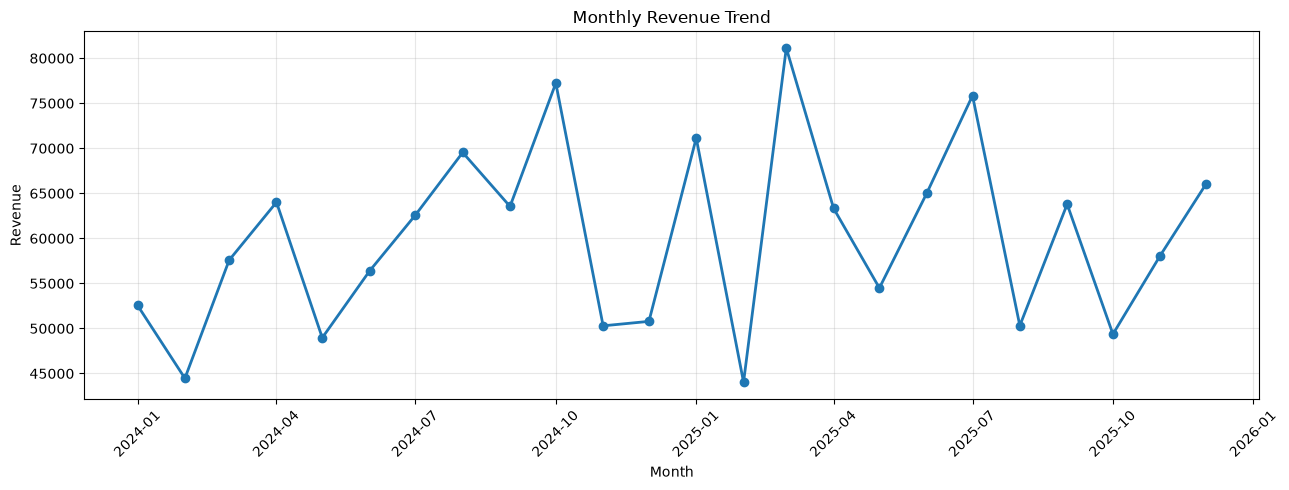

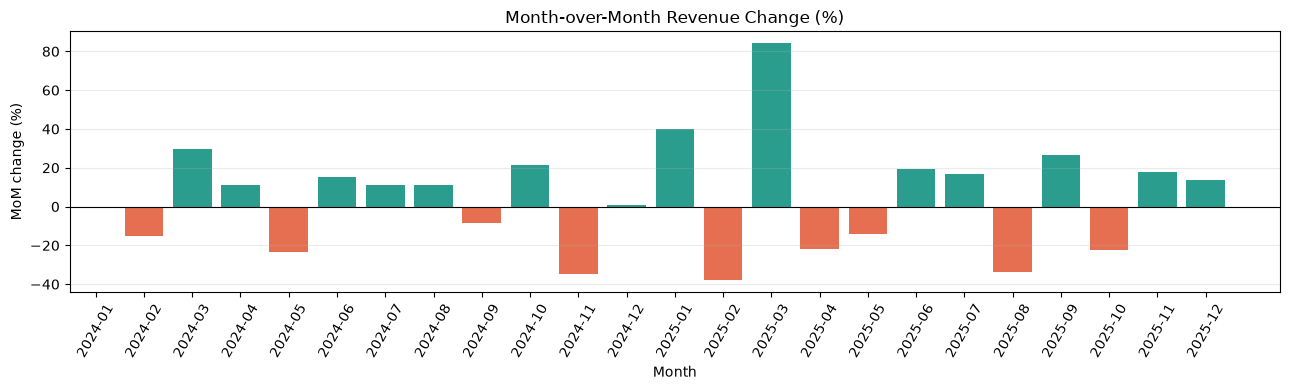

Largest positive MoM change:


,month,revenue,mom_change_pct
14,2025-03-01 00:00:00,81128.29,84.217686


Largest negative MoM change:


,month,revenue,mom_change_pct
13,2025-02-01 00:00:00,44039.36,-38.090387


In [8]:
# 3. Monthly revenue and MoM percentage change
monthly = (
    analysis_df.assign(month=analysis_df["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)["revenue"]
    .sum()
    .sort_values("month")
)
monthly["mom_change_pct"] = monthly["revenue"].pct_change() * 100

display(monthly.style.format({
    "revenue": "{:,.2f}",
    "mom_change_pct": "{:+.2f}%"
}))

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly["month"], monthly["revenue"], marker="o", linewidth=2)
ax1.set_title("Monthly Revenue Trend")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")
ax1.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 4))
colors = ["#2a9d8f" if x >= 0 else "#e76f51" for x in monthly["mom_change_pct"].fillna(0)]
plt.bar(monthly["month"].dt.strftime("%Y-%m"), monthly["mom_change_pct"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Month-over-Month Revenue Change (%)")
plt.xlabel("Month")
plt.ylabel("MoM change (%)")
plt.xticks(rotation=60)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Largest positive MoM change:")
display(monthly.loc[monthly["mom_change_pct"].idxmax()].to_frame().T if monthly["mom_change_pct"].notna().any() else monthly.head(0))
print("Largest negative MoM change:")
display(monthly.loc[monthly["mom_change_pct"].idxmin()].to_frame().T if monthly["mom_change_pct"].notna().any() else monthly.head(0))


TOP 3 CATEGORIES BY REVENUE


,product_category,total_revenue,transactions,units_sold,revenue_share_pct
2,Electronics,"839,986.17",1351,3830,58.31%
3,Home & Kitchen,"237,532.73",1375,3868,16.49%
0,Apparel,"162,373.43",1502,4304,11.27%


BOTTOM 3 CATEGORIES BY REVENUE


,product_category,total_revenue,transactions,units_sold,revenue_share_pct
1,Beauty,"48,810.54",930,2672,3.39%
4,Sports,"151,800.77",842,2326,10.54%
0,Apparel,"162,373.43",1502,4304,11.27%


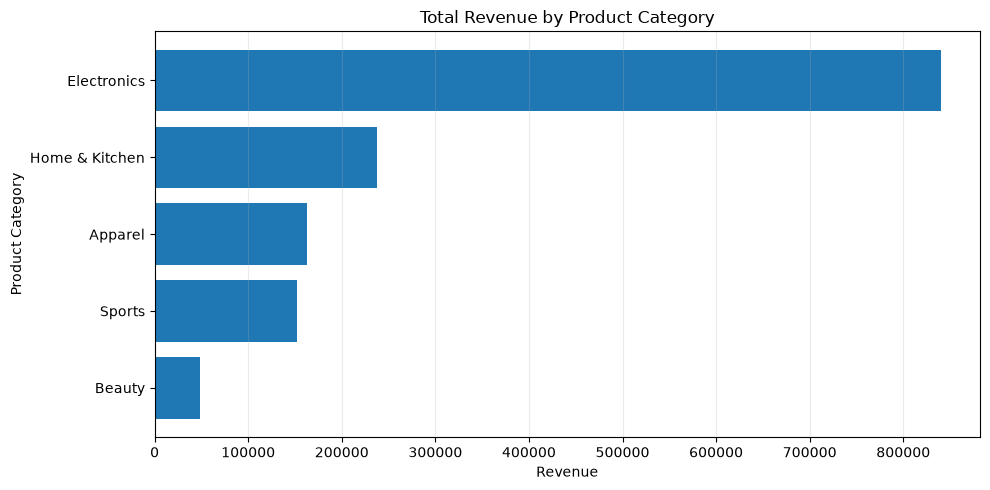

In [9]:
# 4. Category revenue ranking
# Handle datasets that do not contain units_sold by falling back to row counts instead.
if "units_sold" in analysis_df.columns:
    agg_dict = {
        "total_revenue": ("revenue", "sum"),
        "transactions": ("transaction_id", "nunique"),
        "units_sold": ("units_sold", "sum"),
    }
else:
    agg_dict = {
        "total_revenue": ("revenue", "sum"),
        "transactions": ("transaction_id", "nunique"),
        "units_sold": ("revenue", "size"),
    }

category_revenue = (
    analysis_df.groupby("product_category", as_index=False)
    .agg(**agg_dict)
    .sort_values("total_revenue", ascending=False)
)
category_revenue["revenue_share_pct"] = (
    category_revenue["total_revenue"] / category_revenue["total_revenue"].sum() * 100
)

# Keep the output consistent even if a category is missing or the dataset is small.
top3 = category_revenue.head(3)
bottom3 = category_revenue.tail(3).sort_values("total_revenue")

print("TOP 3 CATEGORIES BY REVENUE")
display(top3.style.format({"total_revenue": "{:,.2f}", "revenue_share_pct": "{:.2f}%"}))
print("BOTTOM 3 CATEGORIES BY REVENUE")
display(bottom3.style.format({"total_revenue": "{:,.2f}", "revenue_share_pct": "{:.2f}%"}))

plot_data = category_revenue.sort_values("total_revenue")
plt.figure(figsize=(10, 5))
plt.barh(plot_data["product_category"], plot_data["total_revenue"])
plt.title("Total Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


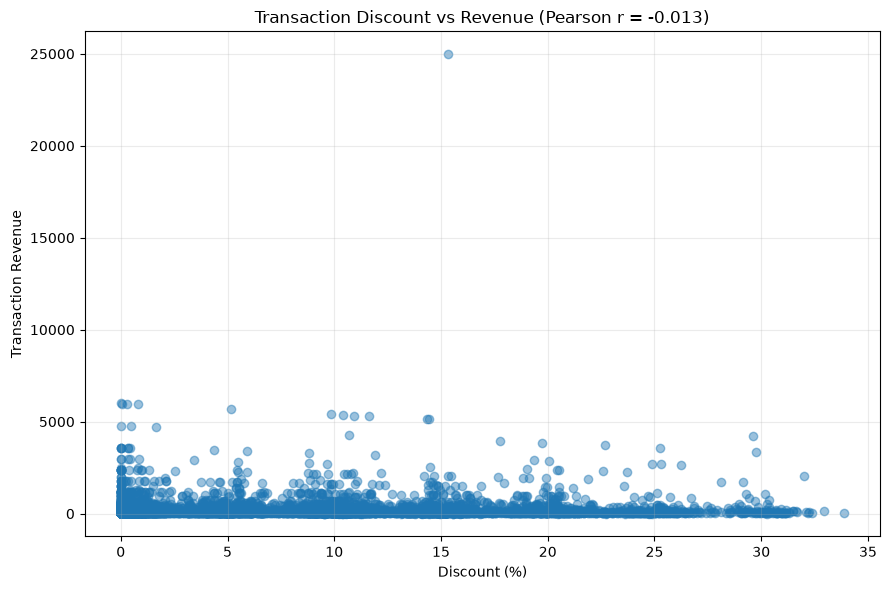

Pearson correlation:  -0.0127
Spearman correlation: -0.0533
Number of transactions included: 6000


In [10]:
# 5. Discount percentage vs transaction revenue
corr_data = analysis_df[["discount_pct", "revenue"]].dropna()
pearson_corr = corr_data["discount_pct"].corr(corr_data["revenue"], method="pearson")
spearman_corr = corr_data["discount_pct"].corr(corr_data["revenue"], method="spearman")

plt.figure(figsize=(9, 6))
plt.scatter(corr_data["discount_pct"], corr_data["revenue"], alpha=0.45)
plt.title(f"Transaction Discount vs Revenue (Pearson r = {pearson_corr:.3f})")
plt.xlabel("Discount (%)")
plt.ylabel("Transaction Revenue")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Pearson correlation:  {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
print("Number of transactions included:", len(corr_data))


Q1: 41.55
Q3: 224.59
IQR: 183.04
Lower outlier bound: -233.01
Upper outlier bound: 499.16
Outlier transactions: 640 (10.67% of analyzed rows)


,transaction_id,date,store_id,product_category,sku,units_sold,revenue,discount_pct,customer_id,region,channel
3585,TXN-005345,2025-03-08,SOUTH-03,Apparel,APP-3003,5,24974.00,15.34,CUST-00210,South,Online
4049,TXN-001223,2025-04-30,NORTH-03,Electronics,ELEC-1003,10,5990.00,0.00,CUST-01312,North,Online
2439,TXN-003799,2024-10-18,SOUTH-02,Electronics,ELEC-1003,10,5985.91,0.07,CUST-00844,South,In-store
4419,TXN-002295,2025-06-14,NORTH-02,Electronics,ELEC-1003,10,5972.22,0.30,CUST-01649,North,Online
5918,TXN-002729,2025-12-20,CENTRAL-01,Electronics,ELEC-1003,10,5940.50,0.83,CUST-01733,Central,In-store
...,...,...,...,...,...,...,...,...,...,...,...
3694,TXN-001322,2025-03-22,CENTRAL-02,Sports,SPRT-5001,10,499.90,0.00,CUST-00024,Central,Online
3667,TXN-004539,2025-03-18,CENTRAL-03,Electronics,ELEC-1001,2,499.89,0.02,CUST-00840,Central,In-store
2294,TXN-005673,2024-10-01,CENTRAL-02,Electronics,ELEC-1003,1,499.76,16.57,CUST-00926,Central,In-store
1523,TXN-002892,2024-07-04,CENTRAL-01,Electronics,ELEC-1001,2,499.66,0.06,CUST-01344,Central,Online


C:\Users\Asus\AppData\Local\Temp\ipykernel_22476\2394260449.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(analysis_df["revenue"].dropna(), vert=True, showfliers=True)


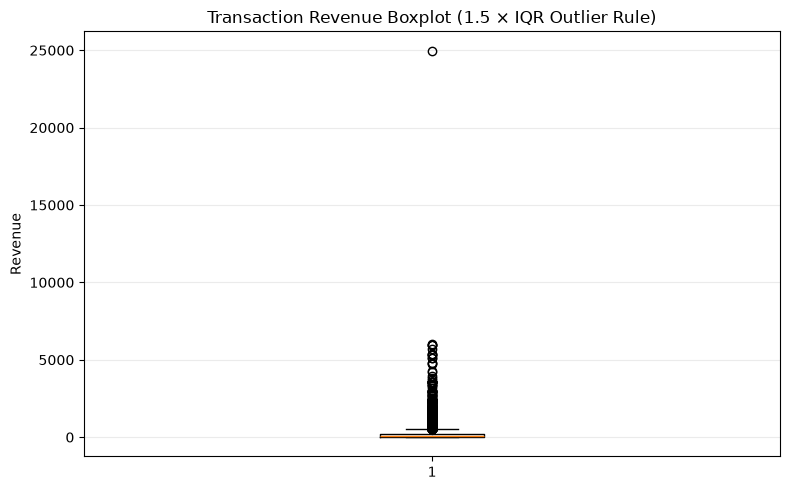

In [11]:
# 6. Identify revenue outliers using the 1.5 x IQR rule
q1 = analysis_df["revenue"].quantile(0.25)
q3 = analysis_df["revenue"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = analysis_df[
    (analysis_df["revenue"] < lower_bound) |
    (analysis_df["revenue"] > upper_bound)
].copy()

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower outlier bound: {lower_bound:,.2f}")
print(f"Upper outlier bound: {upper_bound:,.2f}")
print(f"Outlier transactions: {len(outliers):,} ({len(outliers)/len(analysis_df)*100:.2f}% of analyzed rows)")

outlier_columns = [c for c in [
    "transaction_id", "date", "store_id", "product_category", "sku",
    "units_sold", "revenue", "discount_pct", "customer_id", "region", "channel"
] if c in outliers.columns]
display(outliers[outlier_columns].sort_values("revenue", ascending=False))

plt.figure(figsize=(8, 5))
plt.boxplot(analysis_df["revenue"].dropna(), vert=True, showfliers=True)
plt.title("Transaction Revenue Boxplot (1.5 × IQR Outlier Rule)")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


,channel,total_revenue,transactions,avg_transaction_revenue,avg_discount_pct,units_sold,revenue_share_pct
0,In-store,"909,745.33",3861,235.62,8.24%,10853,63.15%
1,Online,"530,758.31",2139,248.13,8.49%,6147,36.85%


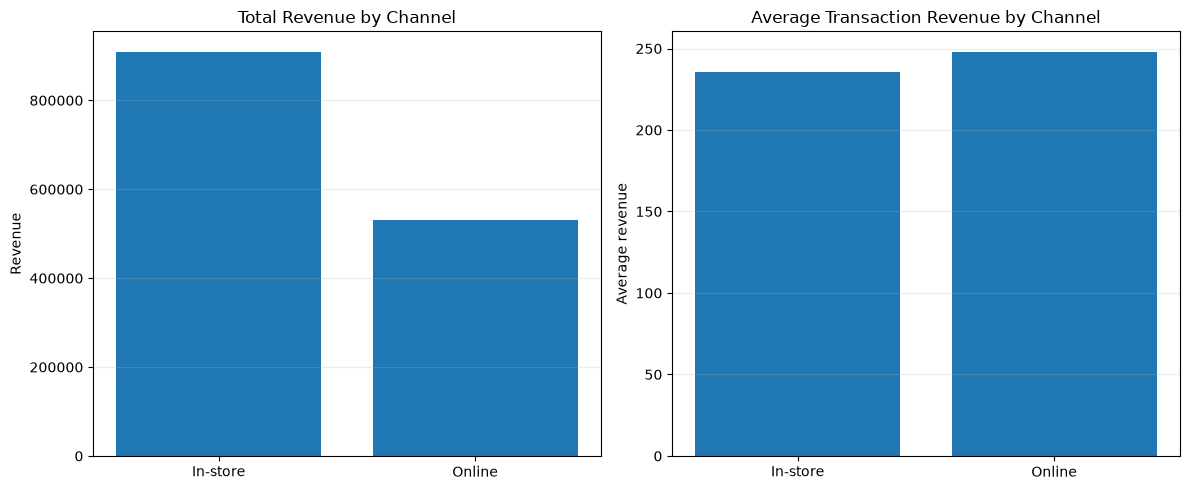

In [12]:
# 7. Channel performance comparison
agg_dict = {
    "total_revenue": ("revenue", "sum"),
    "transactions": ("transaction_id", "nunique"),
    "avg_transaction_revenue": ("revenue", "mean"),
    "avg_discount_pct": ("discount_pct", "mean")
}
if "units_sold" in analysis_df.columns:
    agg_dict["units_sold"] = ("units_sold", "sum")

channel_perf = analysis_df.groupby("channel").agg(**agg_dict).reset_index()
channel_perf["revenue_share_pct"] = (
    channel_perf["total_revenue"] / channel_perf["total_revenue"].sum() * 100
)
channel_perf["avg_transaction_revenue"] = channel_perf["avg_transaction_revenue"].round(2)
channel_perf["avg_discount_pct"] = channel_perf["avg_discount_pct"].round(2)

display(channel_perf.style.format({
    "total_revenue": "{:,.2f}",
    "avg_transaction_revenue": "{:,.2f}",
    "avg_discount_pct": "{:.2f}%",
    "revenue_share_pct": "{:.2f}%"
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(channel_perf["channel"], channel_perf["total_revenue"])
axes[0].set_title("Total Revenue by Channel")
axes[0].set_ylabel("Revenue")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(channel_perf["channel"], channel_perf["avg_transaction_revenue"])
axes[1].set_title("Average Transaction Revenue by Channel")
axes[1].set_ylabel("Average revenue")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [13]:
# 8. Export evidence tables to Excel
output_file = "retail_sales_kpi_evidence.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    monthly.to_excel(writer, sheet_name="Monthly_Revenue", index=False)
    category_revenue.to_excel(writer, sheet_name="Category_Ranking", index=False)
    channel_perf.to_excel(writer, sheet_name="Channel_Comparison", index=False)
    outliers[outlier_columns].to_excel(writer, sheet_name="Revenue_Outliers", index=False)
    pd.DataFrame({
        "metric": ["Pearson correlation", "Spearman correlation", "IQR Q1", "IQR Q3", "IQR", "Lower bound", "Upper bound"],
        "value": [pearson_corr, spearman_corr, q1, q3, iqr, lower_bound, upper_bound]
    }).to_excel(writer, sheet_name="Method_Statistics", index=False)

print(f"Evidence workbook saved as: {output_file}")


Evidence workbook saved as: retail_sales_kpi_evidence.xlsx
